# HydroGraph Project Part 2: Anomaly Detection

In [2]:
cd /Users/ijiho/Desktop/HydroGraph

/Users/ijiho/Desktop/HydroGraph


## 1. Load Data

In [3]:
import pandas as pd

pipes = pd.read_csv("data/pipes_data.csv")
pipes.head()

,WIDTH,MATERIAL,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE
0,250.0,PVC,62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06,34.0,0.016268
1,300.0,PVC,26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06,36.0,0.003077
2,250.0,PVC,20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06,40.0,0.004115
3,250.0,PVC,88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06,41.0,0.003413
4,900.0,CONC,85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06,43.0,0.010906


## 2. Data Preprocessing

In [4]:
X = pd.get_dummies(pipes)
X.head()

,WIDTH,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE,MATERIAL_ABS,MATERIAL_AC,...,MATERIAL_CSPA,MATERIAL_DI,MATERIAL_PB,MATERIAL_PE,MATERIAL_PFR,MATERIAL_PVC,MATERIAL_PVCC,MATERIAL_SS,MATERIAL_ST,MATERIAL_UNK
0,250.0,62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06,34.0,0.016268,False,False,...,False,False,False,False,False,True,False,False,False,False
1,300.0,26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06,36.0,0.003077,False,False,...,False,False,False,False,False,True,False,False,False,False
2,250.0,20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06,40.0,0.004115,False,False,...,False,False,False,False,False,True,False,False,False,False
3,250.0,88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06,41.0,0.003413,False,False,...,False,False,False,False,False,True,False,False,False,False
4,900.0,85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06,43.0,0.010906,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_scaled = ss.fit_transform(X)

## 3. Anomaly Detection

### 3.1 Isolation Forest

In [6]:
from sklearn.ensemble import IsolationForest

if_model = IsolationForest(random_state=42)

if_model.fit(X_scaled)

scores_if = if_model.score_samples(X_scaled)
preds_if = if_model.predict(X_scaled)

### 3.1.1 Visualization

In [7]:
%pip install --upgrade "numpy==2.4.*"


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import umap

X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

/Users/ijiho/Desktop/HydroGraph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ijiho/Desktop/HydroGraph/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ijiho/Desktop/HydroGraph/.venv/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


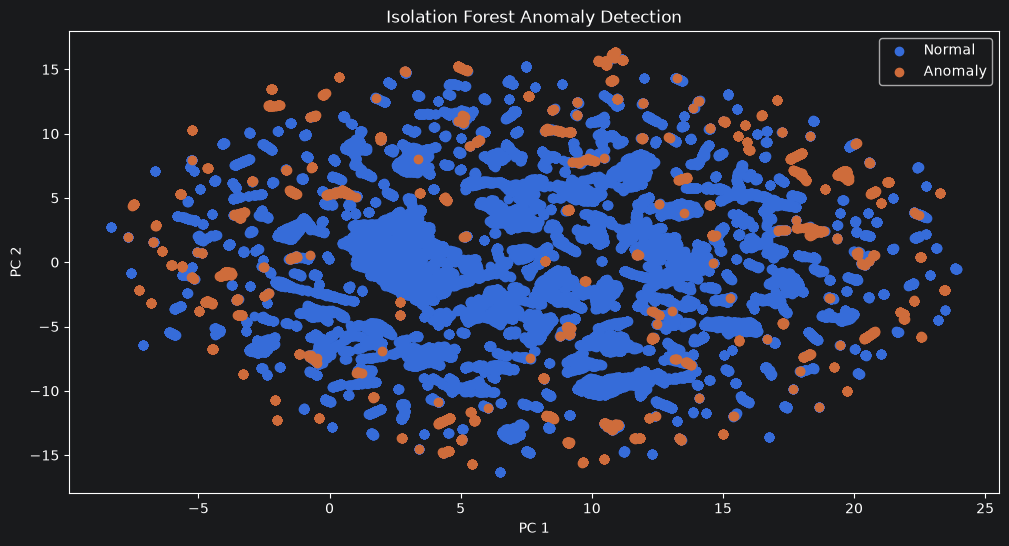

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

normal_if = preds_if == 1
anomaly_if = preds_if == -1

plt.scatter(
    X_umap[normal_if, 0],
    X_umap[normal_if, 1],
    label="Normal"
)

plt.scatter(
    X_umap[anomaly_if, 0],
    X_umap[anomaly_if, 1],
    label="Anomaly"
)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()

In [10]:
from sklearn.manifold import trustworthiness

trustworthiness(X_scaled, X_umap)

np.float64(0.9983652695922443)

## 3.2 Local Outlier Factor

In [11]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor()
preds_lof = lof.fit_predict(X_scaled)

scores_lof = lof.negative_outlier_factor_

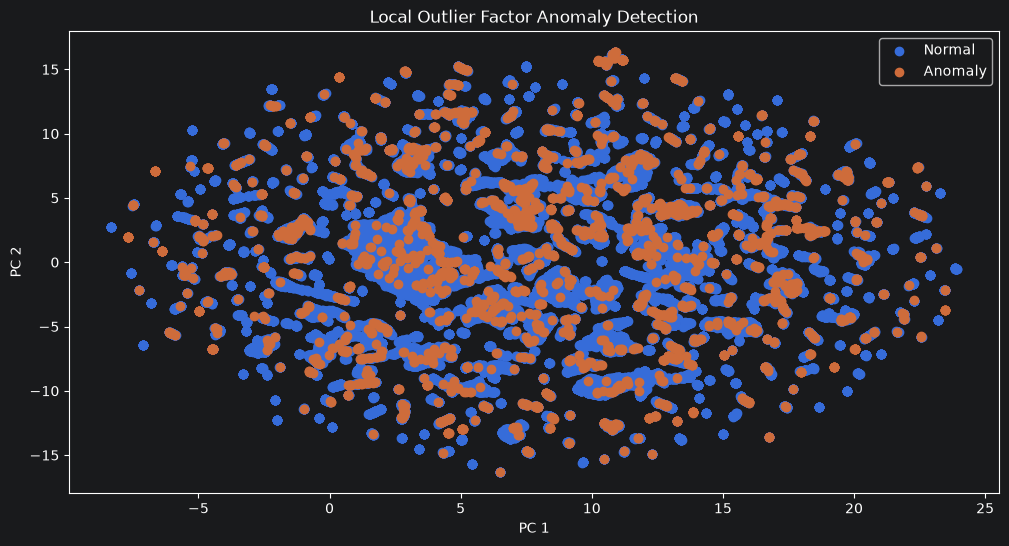

In [12]:
plt.figure(figsize=(12, 6))

normal_lof = preds_lof == 1
anomaly_lof = preds_lof == -1

plt.scatter(
    X_umap[normal_lof, 0],
    X_umap[normal_lof, 1],
    label="Normal"
)

plt.scatter(
    X_umap[anomaly_lof, 0],
    X_umap[anomaly_lof, 1],
    label="Anomaly"
)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.title("Local Outlier Factor Anomaly Detection")
plt.show()

## 4. Analysis

In [23]:
pipes_with_scores

,WIDTH,MATERIAL,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE,if_score,lof_score
0,250.0,PVC,62.7,-8.463015e+06,5.676546e+06,-8.462955e+06,5.676480e+06,34.0,0.016268,-0.433439,-1.026594
1,300.0,PVC,26.0,-8.450683e+06,5.672344e+06,-8.450704e+06,5.672374e+06,36.0,0.003077,-0.398845,-1.302635
2,250.0,PVC,20.9,-8.408926e+06,5.692079e+06,-8.408955e+06,5.692069e+06,40.0,0.004115,-0.392791,-1.002828
3,250.0,PVC,88.2,-8.409039e+06,5.691435e+06,-8.409098e+06,5.691545e+06,41.0,0.003413,-0.405757,-1.027223
4,900.0,CONC,85.0,-8.410044e+06,5.694131e+06,-8.410049e+06,5.694175e+06,43.0,0.010906,-0.500697,-1.072289
...,...,...,...,...,...,...,...,...,...,...,...
56075,200.0,PVC,13.0,-8.406966e+06,5.692156e+06,-8.406949e+06,5.692163e+06,0.0,0.003077,-0.414827,-0.988859
56076,200.0,PVC,41.5,-8.406949e+06,5.692163e+06,-8.406926e+06,5.692108e+06,2.0,0.003132,-0.407302,-1.001145
56077,200.0,PVC,10.4,-8.406979e+06,5.692045e+06,-8.406984e+06,5.692032e+06,0.0,0.004808,-0.415321,-0.978088
56078,200.0,PVC,15.7,-8.406947e+06,5.691971e+06,-8.406927e+06,5.691980e+06,0.0,0.003185,-0.413674,-0.974484


## 4.1 Anomalies Distribution Analysis

In [13]:
if_anomalies = X[anomaly_if]
if_anomalies.info()

<class 'pandas.DataFrame'>
Index: 4353 entries, 4 to 56042
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WIDTH           4353 non-null   float64
 1   LENGTHASBUILT   4353 non-null   float64
 2   x1              4353 non-null   float64
 3   y1              4353 non-null   float64
 4   x2              4353 non-null   float64
 5   y2              4353 non-null   float64
 6   AGE             4353 non-null   float64
 7   SLOPE           4353 non-null   float64
 8   MATERIAL_ABS    4353 non-null   bool   
 9   MATERIAL_AC     4353 non-null   bool   
 10  MATERIAL_BRICK  4353 non-null   bool   
 11  MATERIAL_CI     4353 non-null   bool   
 12  MATERIAL_CLAY   4353 non-null   bool   
 13  MATERIAL_CONC   4353 non-null   bool   
 14  MATERIAL_CONPP  4353 non-null   bool   
 15  MATERIAL_CONR   4353 non-null   bool   
 16  MATERIAL_CONX   4353 non-null   bool   
 17  MATERIAL_CORI   4353 non-null   bool   
 18  MAT

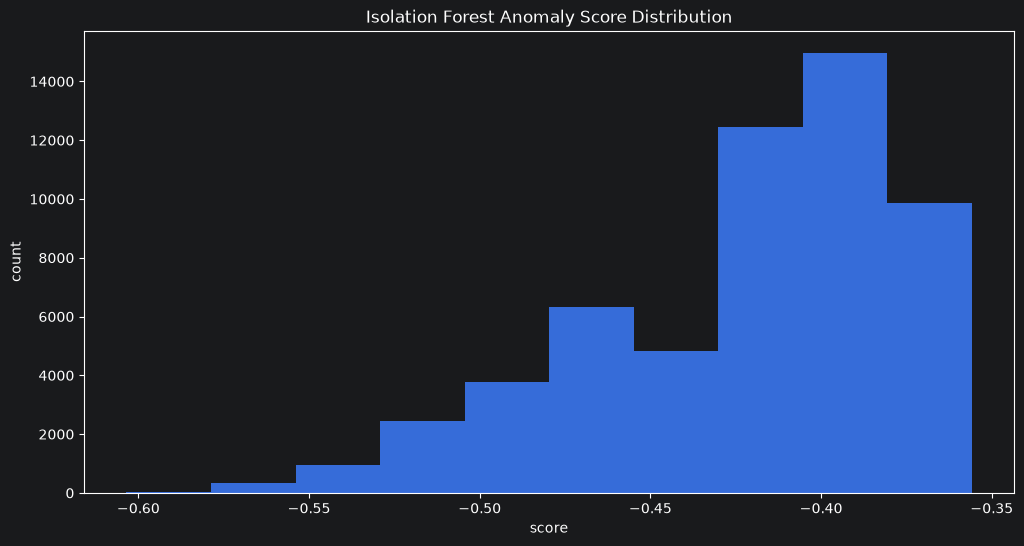

In [14]:
plt.figure(figsize=(12, 6))
plt.hist(scores_if)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("score")
plt.ylabel("count")
plt.show()

Isolation Forest scores followed a negatively skewed distribution, indicating that while most pipes fell within a normal range, a small subset exhibited highly anomalous characteristics.

In [15]:
lof_anomalies = X[anomaly_lof]
lof_anomalies.info()

<class 'pandas.DataFrame'>
Index: 3299 entries, 53 to 56042
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WIDTH           3299 non-null   float64
 1   LENGTHASBUILT   3299 non-null   float64
 2   x1              3299 non-null   float64
 3   y1              3299 non-null   float64
 4   x2              3299 non-null   float64
 5   y2              3299 non-null   float64
 6   AGE             3299 non-null   float64
 7   SLOPE           3299 non-null   float64
 8   MATERIAL_ABS    3299 non-null   bool   
 9   MATERIAL_AC     3299 non-null   bool   
 10  MATERIAL_BRICK  3299 non-null   bool   
 11  MATERIAL_CI     3299 non-null   bool   
 12  MATERIAL_CLAY   3299 non-null   bool   
 13  MATERIAL_CONC   3299 non-null   bool   
 14  MATERIAL_CONPP  3299 non-null   bool   
 15  MATERIAL_CONR   3299 non-null   bool   
 16  MATERIAL_CONX   3299 non-null   bool   
 17  MATERIAL_CORI   3299 non-null   bool   
 18  MA

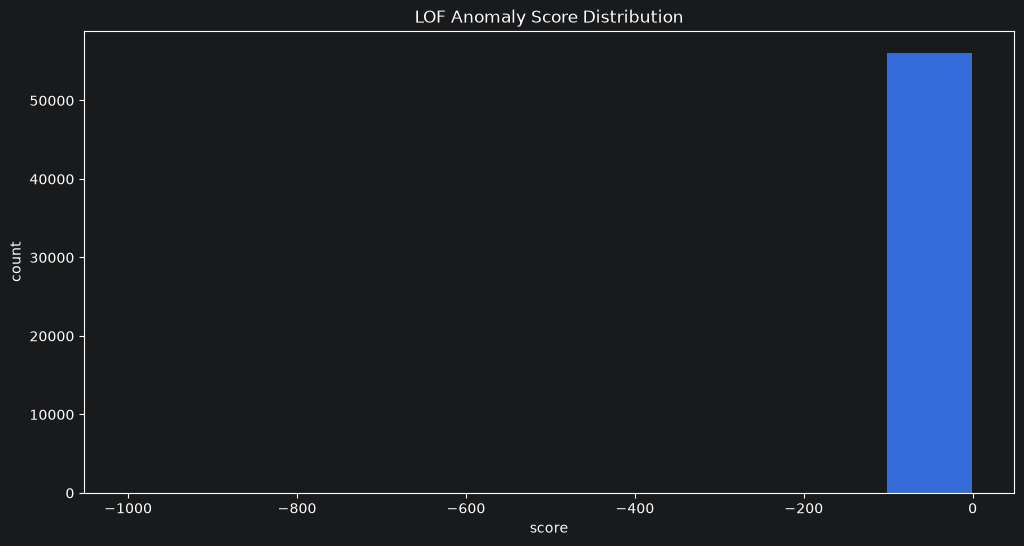

In [16]:
plt.figure(figsize=(12, 6))
plt.hist(scores_lof)
plt.title("LOF Anomaly Score Distribution")
plt.xlabel("score")
plt.ylabel("count")
plt.show()

An overwhelming majority fell into the same numerical range of anomaly scores, while LOF detected a small number of severely anomolous samples.

## 4.2 Top 100 Highest Anomaly Scores Analysis

In [17]:
pipes_with_scores = pipes
pipes_with_scores["if_score"] = scores_if
pipes_with_scores["lof_score"] = scores_lof

In [18]:
top100if = pipes_with_scores.sort_values(by="if_score")[:100]
top100if

,WIDTH,MATERIAL,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE,if_score,lof_score
54405,525.0,UNK,13.0,-8.405890e+06,5.689814e+06,-8.405906e+06,5.689804e+06,12.0,6.069385,-0.603489,-3.312968
33859,200.0,PE,2140.0,-8.452887e+06,5.646681e+06,-8.452816e+06,5.646598e+06,21.0,0.009362,-0.600662,-1.763132
47614,135.0,UNK,4.3,-8.452145e+06,5.677895e+06,-8.452141e+06,5.677899e+06,12.0,16.039535,-0.600370,-1.590979
36328,250.0,UNK,44.2,-8.453402e+06,5.647806e+06,-8.453408e+06,5.647868e+06,52.0,0.040204,-0.593527,-4.570987
33864,200.0,PE,1225.0,-8.448996e+06,5.646117e+06,-8.447688e+06,5.647255e+06,21.0,0.008245,-0.592674,-1.582269
...,...,...,...,...,...,...,...,...,...,...,...
21690,600.0,CONR,233.0,-8.399701e+06,5.696333e+06,-8.399744e+06,5.696386e+06,24.0,0.001717,-0.571264,-1.159718
35584,1650.0,CONR,158.3,-8.447198e+06,5.678914e+06,-8.447408e+06,5.678993e+06,55.0,0.002097,-0.571259,-1.003183
39927,250.0,UNK,43.4,-8.451203e+06,5.663720e+06,-8.451200e+06,5.663782e+06,43.0,2.531797,-0.571131,-10.491503
10116,750.0,CONR,252.3,-8.401698e+06,5.697936e+06,-8.401895e+06,5.698229e+06,24.0,0.000951,-0.571032,-1.627759


In [19]:
top100lof = pipes_with_scores.sort_values(by="lof_score")[:100]
top100lof

,WIDTH,MATERIAL,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE,if_score,lof_score
47493,250.0,PB,7.0,-8.434361e+06,5.658891e+06,-8.434361e+06,5.658901e+06,9.0,0.007857,-0.428079,-1001.928853
40257,250.0,PB,80.1,-8.430511e+06,5.667773e+06,-8.430412e+06,5.667828e+06,32.0,0.003995,-0.381060,-887.231933
17249,250.0,CORI,39.6,-8.425566e+06,5.689646e+06,-8.425518e+06,5.689675e+06,62.0,0.006263,-0.399128,-639.598216
6165,250.0,PB,14.0,-8.418984e+06,5.677104e+06,-8.418974e+06,5.677122e+06,41.0,0.007857,-0.385656,-556.846841
5454,250.0,CSP,39.6,-8.425756e+06,5.689962e+06,-8.425708e+06,5.689991e+06,39.0,0.005354,-0.391409,-500.564043
...,...,...,...,...,...,...,...,...,...,...,...
16071,250.0,CONR,30.5,-8.409285e+06,5.694771e+06,-8.409322e+06,5.694748e+06,47.0,-1.943934,-0.519143,-5.651140
51478,100.0,PE,77.8,-8.464513e+06,5.671085e+06,-8.464511e+06,5.671092e+06,5.0,-1.459640,-0.547936,-5.619516
9491,200.0,AC,19.6,-8.426323e+06,5.691558e+06,-8.426320e+06,5.691530e+06,64.0,2.744388,-0.546202,-5.594788
49983,150.0,PVC,51.3,-8.407069e+06,5.692301e+06,-8.407086e+06,5.692308e+06,7.0,-1.723392,-0.436164,-5.585118


In [35]:
# intersection between the Top 100s
intersection = pd.merge(top100if, top100lof, how='inner')
intersection

,WIDTH,MATERIAL,LENGTHASBUILT,x1,y1,x2,y2,AGE,SLOPE,if_score,lof_score
0,1200.0,CONX,130.8,-8.404581e+06,5.697560e+06,-8.404706e+06,5.697698e+06,37.0,0.001682,-0.586036,-11.406013
1,600.0,CLAY,5.2,-8.423686e+06,5.691363e+06,-8.423693e+06,5.691367e+06,101.0,-10.456923,-0.585578,-10.060741
2,250.0,UNK,35.5,-8.406807e+06,5.695042e+06,-8.406773e+06,5.694996e+06,38.0,2.371831,-0.580318,-9.274560
3,250.0,UNK,13.7,-8.408475e+06,5.696179e+06,-8.408473e+06,5.696195e+06,49.0,3.705839,-0.572897,-7.887874
4,250.0,UNK,25.4,-8.406964e+06,5.694227e+06,-8.406996e+06,5.694209e+06,43.0,3.283858,-0.572659,-10.254248
5,250.0,UNK,43.4,-8.451203e+06,5.663720e+06,-8.451200e+06,5.663782e+06,43.0,2.531797,-0.571131,-10.491503


The first pipe likely received a high anomaly score due to its exceptionally large width and length, both of which are rare relative to the overall distribution of pipes in the dataset.

The second pipe likely represents an anomaly because of its unusual combination of characteristics: it is over 100 years old, has a very short length, and exhibits a steep negative slope. While each feature may individually be uncommon, their combination makes this pipe particularly anomalous.

The remaining four consensus anomalies all are made of an unknown (UNK) material. Since UNK represents only approximately 1.7% of the dataset, the rarity of this category likely contributed to their anomaly scores. However, this finding is primarily a consequence of the data distribution rather than an indication of elevated engineering risk. Therefore, these anomalies are less informative from an infrastructure management perspective.

## 4.3 Features Analysis

### 4.3.1 Width

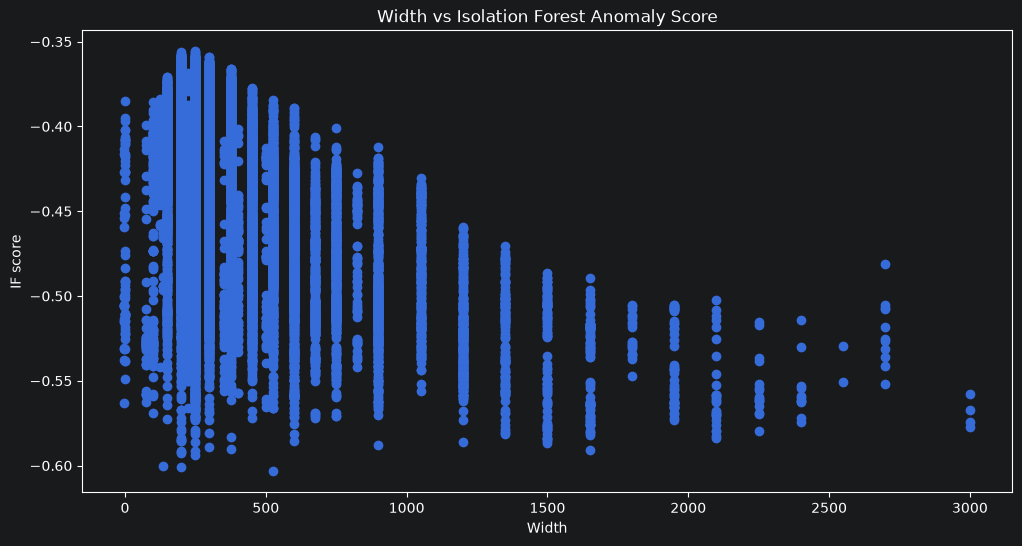

In [21]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["WIDTH"], pipes_with_scores["if_score"])
plt.title("Width vs Isolation Forest Anomaly Score")
plt.xlabel("Width")
plt.ylabel("IF score")
plt.show()

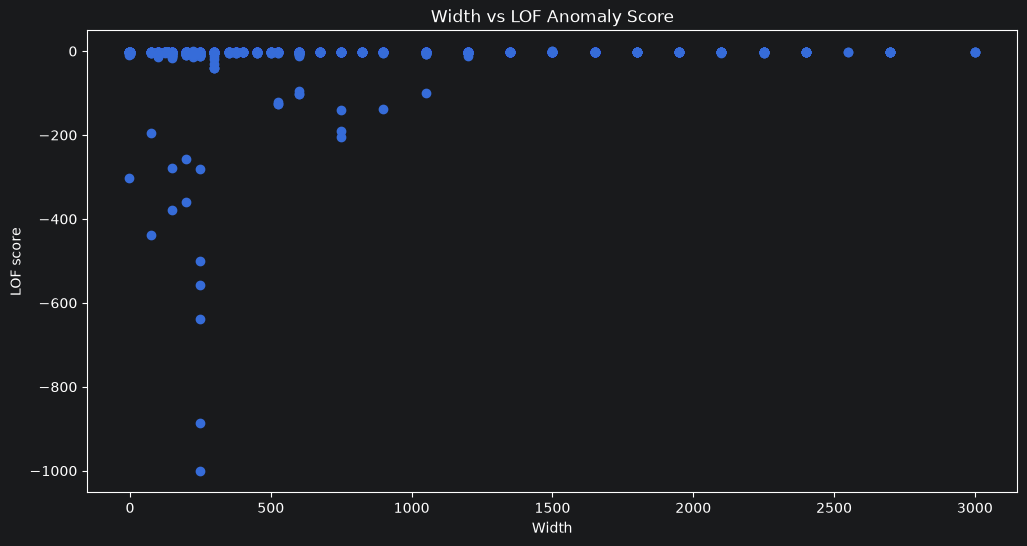

In [22]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["WIDTH"], pipes_with_scores["lof_score"])
plt.title("Width vs LOF Anomaly Score")
plt.xlabel("Width")
plt.ylabel("LOF score")
plt.show()

Data from the Isolation Forest (IF) scores shows a negative trend, with pipe width somewhat influencing the anomaly score. However, scores between pipes of similar lengths vary significantly, and this difference decreases as width increases. Pipes with larger widths typically higher anomaly scores. This is intuitively expected since, as shown in the data analysis notebook’s histogram, the majority of pipes fall within the 0 to 500 range.

Conversely, the Local Outlier Factor (LOF) score graph reveals a different pattern. Most pipes, regardless of width, exhibit low anomaly scores. Interestingly, however, some pipes with lengths between 0 and approximately 250 show unusually high anomaly scores, indicating that an additional factor, correlated with width, is also influencing these scores.

### 4.3.2 LENGTHASBUILT

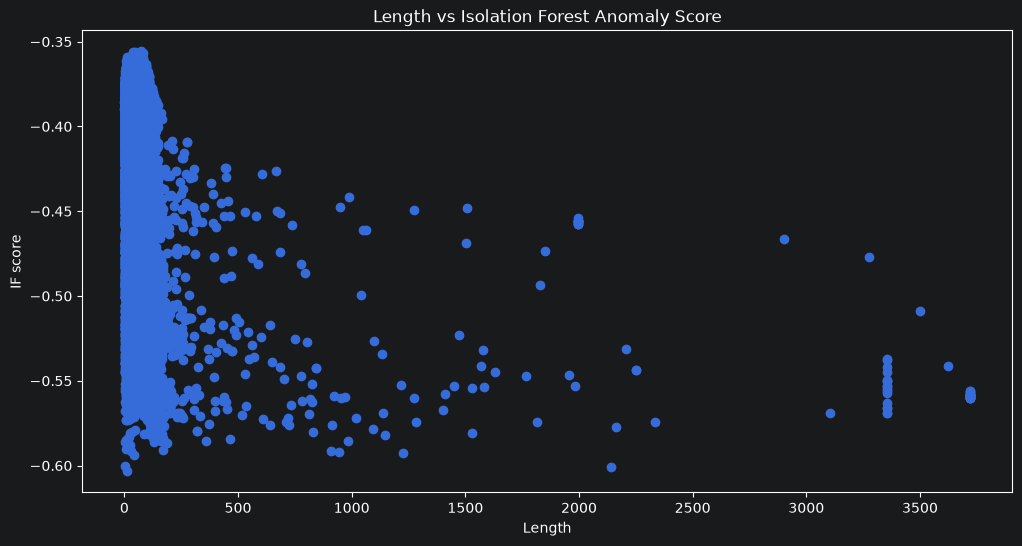

In [24]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["LENGTHASBUILT"], pipes_with_scores["if_score"])
plt.title("Length vs Isolation Forest Anomaly Score")
plt.xlabel("Length")
plt.ylabel("IF score")
plt.show()

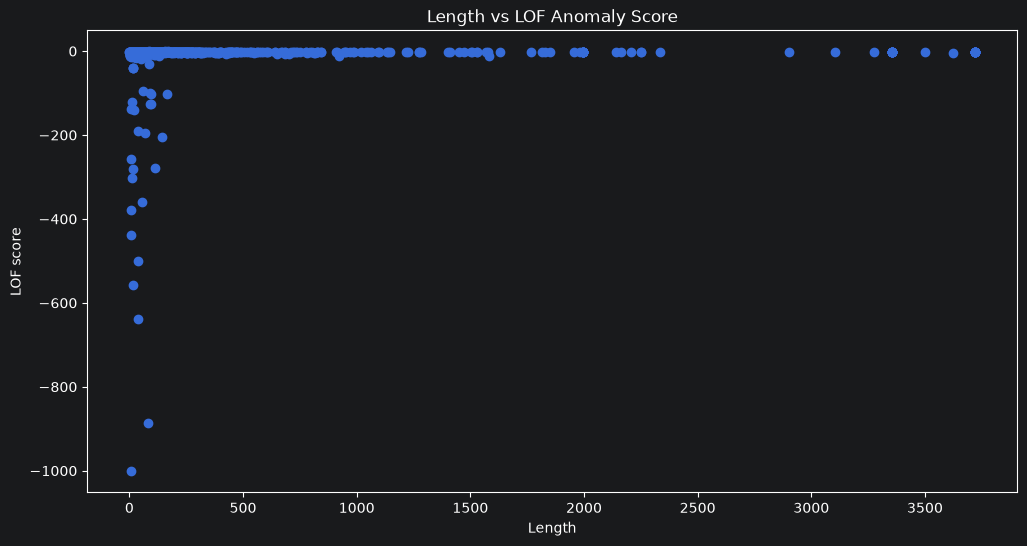

In [25]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["LENGTHASBUILT"], pipes_with_scores["lof_score"])
plt.title("Length vs LOF Anomaly Score")
plt.xlabel("Length")
plt.ylabel("LOF score")
plt.show()

### 4.3.3 Age

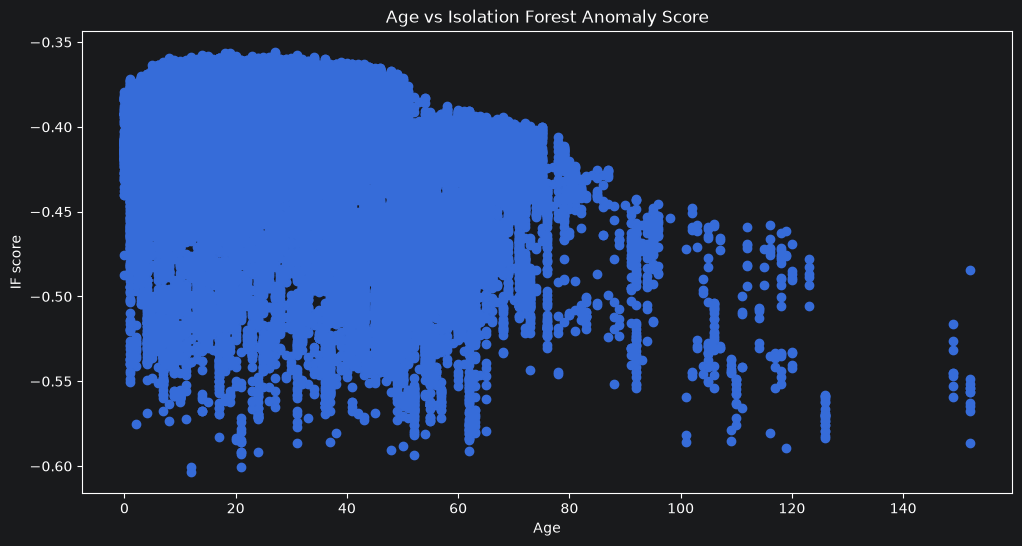

In [26]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["AGE"], pipes_with_scores["if_score"])
plt.title("Age vs Isolation Forest Anomaly Score")
plt.xlabel("Age")
plt.ylabel("IF score")
plt.show()

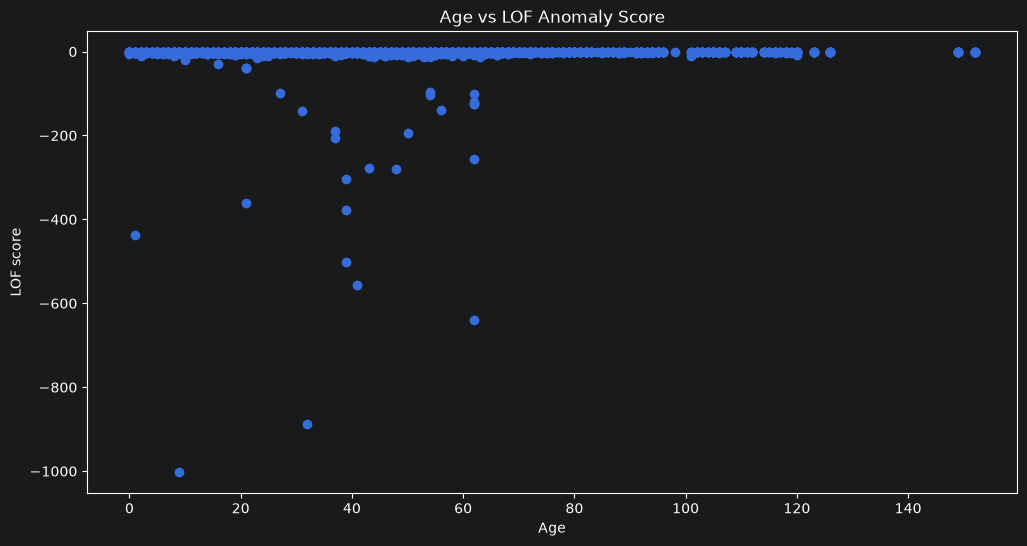

In [27]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["AGE"], pipes_with_scores["lof_score"])
plt.title("Age vs LOF Anomaly Score")
plt.xlabel("Age")
plt.ylabel("LOF score")
plt.show()

### 4.3.4 Slope

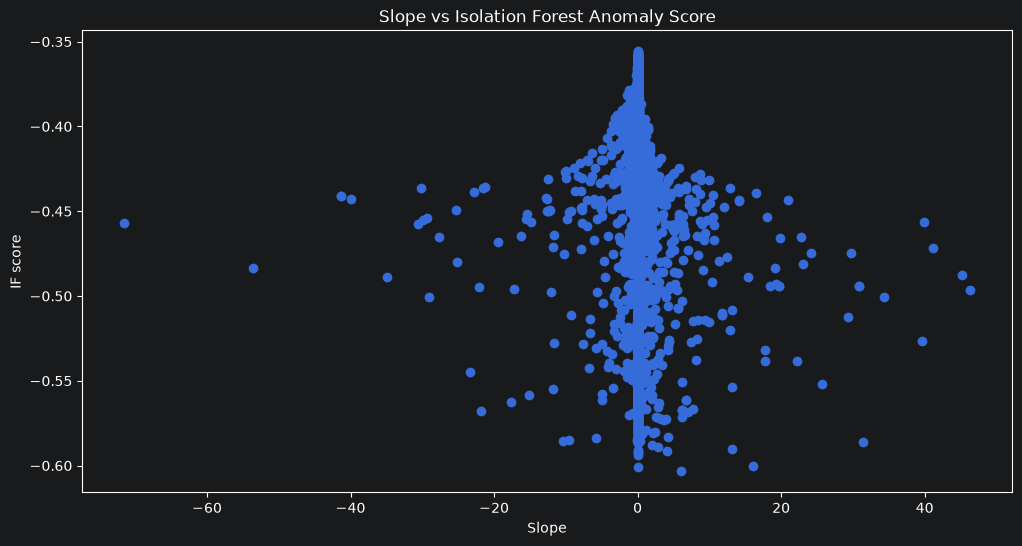

In [28]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["SLOPE"], pipes_with_scores["if_score"])
plt.title("Slope vs Isolation Forest Anomaly Score")
plt.xlabel("Slope")
plt.ylabel("IF score")
plt.show()

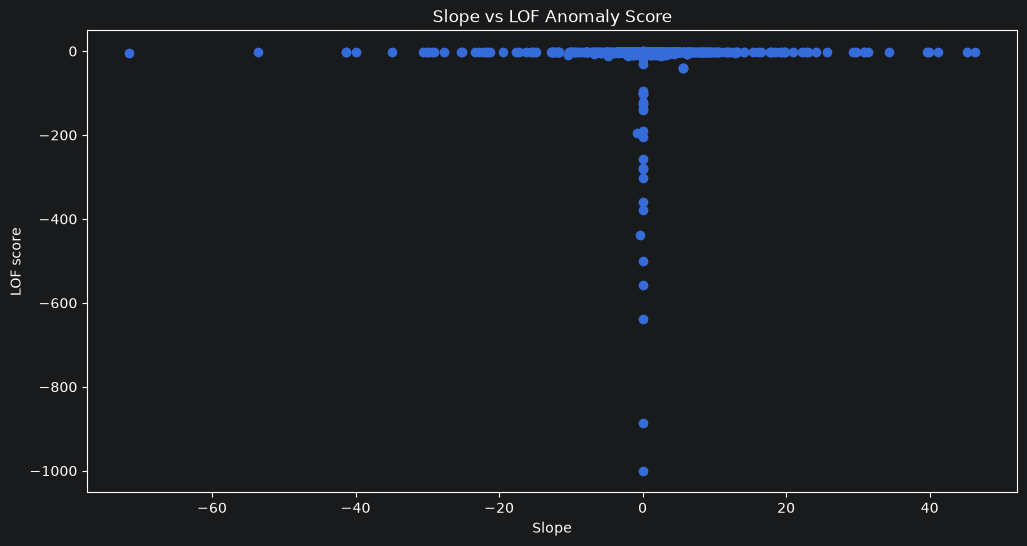

In [29]:
plt.figure(figsize=(12, 6))
plt.scatter(pipes_with_scores["SLOPE"], pipes_with_scores["lof_score"])
plt.title("Slope vs LOF Anomaly Score")
plt.xlabel("Slope")
plt.ylabel("LOF score")
plt.show()

### 4.3.5 Material

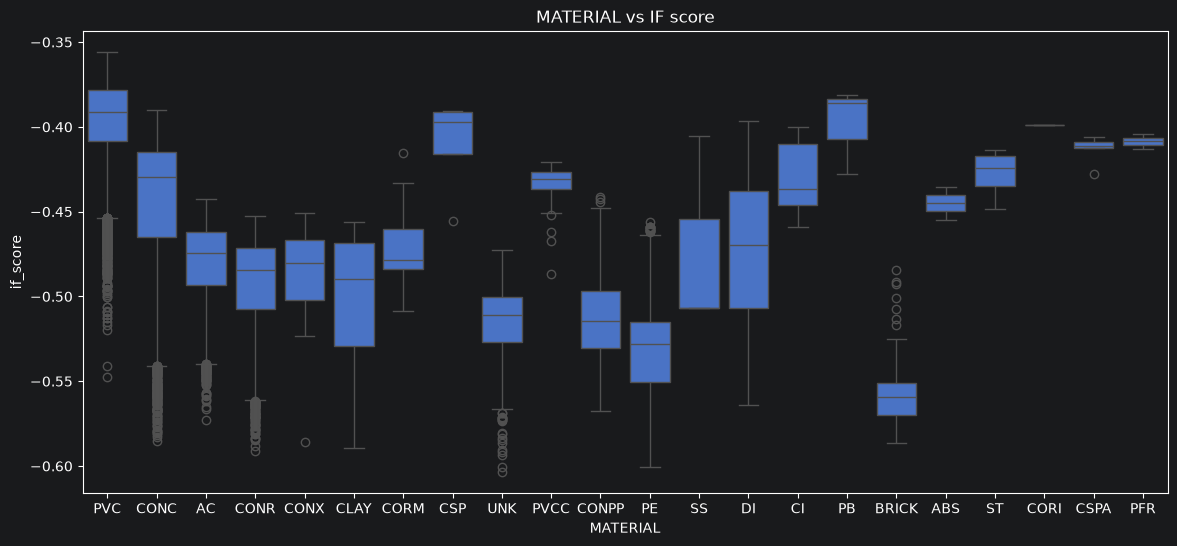

In [33]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(x="MATERIAL", y="if_score", data=pipes_with_scores[["MATERIAL", "if_score"]])
plt.title("MATERIAL vs IF score")
plt.show()

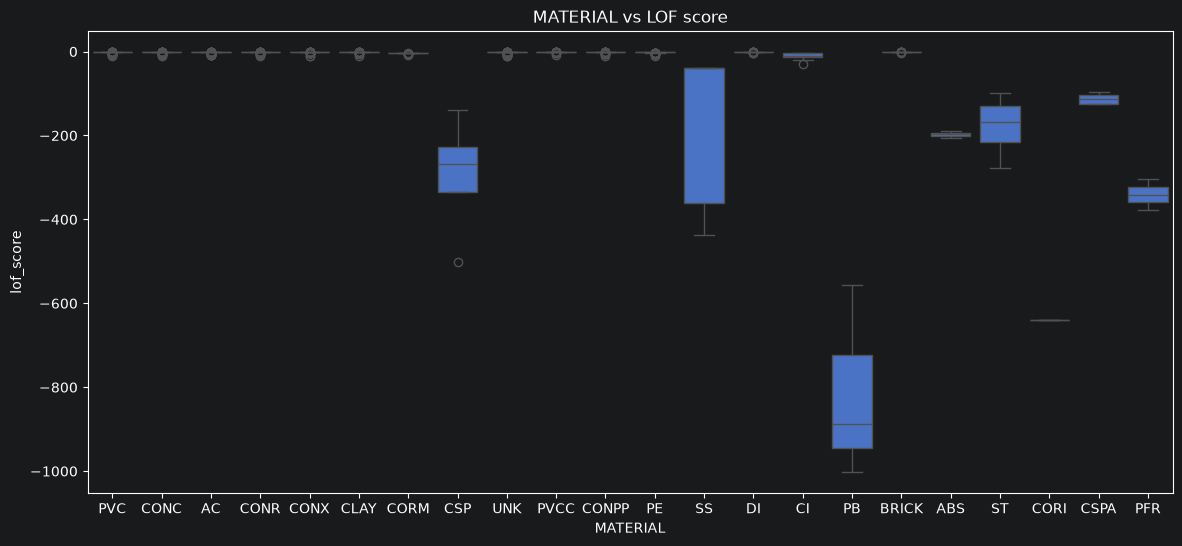

In [34]:
plt.figure(figsize=(14, 6))
sns.boxplot(x="MATERIAL", y="lof_score", data=pipes_with_scores[["MATERIAL", "lof_score"]])
plt.title("MATERIAL vs LOF score")
plt.show()

## 4.4 Spatial Analysis

## 4.5 Comparative Analysis

## 4.6 Findings + Validation from Engineering Literature